# MMDP-OD-RTDP Comparison — Experiment Notebook

This notebook loads the project, visualizes the three benchmark maps, runs the
fixed experiment, and creates the figures and tables used to inspect the results.

The project can be loaded from GitHub, an existing Colab folder, or an uploaded
ZIP. A valid project folder contains `pyproject.toml`, `src/mmdp`, `scripts`, and
`maps`.

The experiment configuration is defined in `src/mmdp/experiments/final_config.py`:

- three benchmark maps
- 1–6 agents
- Baseline RTDP and OD-RTDP
- fixed seed `20260708`
- serial execution in isolated processes
- planning until the initial state is solved or 60 seconds elapse
- five scheduled policy-evaluation episodes
- a 75-second watchdog for each complete condition

All conditions are written to one resumable CSV:

`/content/MMDP_OUTPUT/MMDP_results_final_report.csv`

The analysis creates one peak-memory figure and one planning-outcomes table per map,
plus a combined budgeted policy-evaluation table.


In [1]:
# Choose how to load the project, then run this cell.
# In Google Colab these lines appear as editable form fields.
SOURCE_MODE = "manual_zip"  # @param ["github", "manual_folder", "manual_zip"]
GITHUB_REPOSITORY = "https://github.com/t-rays/MMDP-OD-RTDP-PROJECT.git"  # @param {type:"string"}
MANUAL_PROJECT_PATH = "/content/MMDP-OD-RTDP-PROJECT-CONSOLIDATED"  # @param {type:"string"}

import importlib
import shutil
import subprocess
import sys
import zipfile
from pathlib import Path


def is_project_root(path: Path) -> bool:
    """Return True when path contains the required project structure."""
    return (
        path.is_dir()
        and (path / "pyproject.toml").is_file()
        and (path / "src" / "mmdp").is_dir()
        and (path / "scripts" / "run_compact_matrix.py").is_file()
        and (path / "maps").is_dir()
    )


def find_project_root(search_root: Path) -> Path:
    """Find the project root itself or inside one uploaded/extracted directory."""
    search_root = search_root.expanduser().resolve()
    if is_project_root(search_root):
        return search_root
    if not search_root.exists():
        raise FileNotFoundError(f"Project path does not exist: {search_root}")

    candidates = []
    for pyproject in search_root.rglob("pyproject.toml"):
        candidate = pyproject.parent
        if is_project_root(candidate):
            candidates.append(candidate)

    if not candidates:
        raise FileNotFoundError(
            "No valid project folder was found. The folder must contain "
            "pyproject.toml, src/mmdp, scripts/run_compact_matrix.py, and maps."
        )
    if len(candidates) > 1:
        listed = "\n".join(f"- {path}" for path in candidates)
        raise RuntimeError(
            "More than one valid project folder was found. Set MANUAL_PROJECT_PATH "
            f"to the required folder:\n{listed}"
        )
    return candidates[0]


def safely_extract_zip(zip_path: Path, destination: Path) -> None:
    """Extract a ZIP while rejecting paths that escape the destination."""
    destination = destination.resolve()
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            member_path = (destination / member.filename).resolve()
            if destination != member_path and destination not in member_path.parents:
                raise ValueError(f"Unsafe ZIP entry: {member.filename}")
        archive.extractall(destination)


if SOURCE_MODE == "github":
    repo_dir = Path("/content/MMDP-OD-RTDP-PROJECT")
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    print(f"Cloning repository from {GITHUB_REPOSITORY} ...")
    subprocess.run(
        ["git", "clone", "--depth", "1", GITHUB_REPOSITORY, str(repo_dir)],
        check=True,
    )
    PROJECT_ROOT = find_project_root(repo_dir)

elif SOURCE_MODE == "manual_folder":
    # First upload/copy the complete folder into Colab using the Files panel,
    # Google Drive, or another method; then set MANUAL_PROJECT_PATH above.
    PROJECT_ROOT = find_project_root(Path(MANUAL_PROJECT_PATH))
    print(f"Using manually supplied project folder: {PROJECT_ROOT}")

elif SOURCE_MODE == "manual_zip":
    try:
        from google.colab import files
    except ImportError as exc:
        raise RuntimeError(
            "manual_zip uses the Google Colab upload dialog. Outside Colab, "
            "extract the ZIP yourself and choose manual_folder."
        ) from exc

    print("Choose one ZIP file containing the complete project folder.")
    uploaded = files.upload()
    zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
    if len(zip_names) != 1:
        raise ValueError("Upload exactly one .zip file.")

    upload_root = Path("/content/MMDP_MANUAL_UPLOAD")
    if upload_root.exists():
        shutil.rmtree(upload_root)
    upload_root.mkdir(parents=True)

    zip_path = Path("/content") / zip_names[0]
    # files.upload normally writes into the current directory. This fallback
    # handles notebooks whose current directory is not /content.
    if not zip_path.exists():
        zip_path = Path(zip_names[0]).resolve()
    safely_extract_zip(zip_path, upload_root)
    PROJECT_ROOT = find_project_root(upload_root)
    print(f"Using project extracted from ZIP: {PROJECT_ROOT}")

else:
    raise ValueError(
        "SOURCE_MODE must be 'github', 'manual_folder', or 'manual_zip'."
    )

OUTPUT_DIR = Path("/content/MMDP_OUTPUT")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = OUTPUT_DIR / "MMDP_results_final_report.csv"

# Clear loaded package modules before installing the selected project.
for module_name in list(sys.modules):
    if module_name == "mmdp" or module_name.startswith("mmdp."):
        del sys.modules[module_name]

print("Installing the mmdp package from:", PROJECT_ROOT)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", str(PROJECT_ROOT) + "[notebooks]"],
    check=True,
)
importlib.invalidate_caches()

print("Preparation complete.")
print("SOURCE_MODE:", SOURCE_MODE)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CSV:", RESULTS_CSV)


Choose one ZIP file containing the complete project folder.


Saving MMDP-OD-RTDP-PROJECT-FINAL-CLEAN-GRAPH-TABLE-FIX.zip to MMDP-OD-RTDP-PROJECT-FINAL-CLEAN-GRAPH-TABLE-FIX.zip
Using project extracted from ZIP: /content/MMDP_MANUAL_UPLOAD/MMDP-OD-RTDP-PROJECT-FINAL-CLEAN
Installing the mmdp package from: /content/MMDP_MANUAL_UPLOAD/MMDP-OD-RTDP-PROJECT-FINAL-CLEAN
Preparation complete.
SOURCE_MODE: manual_zip
PROJECT_ROOT: /content/MMDP_MANUAL_UPLOAD/MMDP-OD-RTDP-PROJECT-FINAL-CLEAN
CSV: /content/MMDP_OUTPUT/MMDP_results_final_report.csv


In [2]:
# Map visualization helper.
from functools import partial

from ipywidgets import interact, IntSlider
from mmdp.analysis.notebook_visualizer import plot_map_visualization

plot_map_visualization = partial(plot_map_visualization, maps_root=PROJECT_ROOT / 'maps')

In [3]:
# Serial experiment and analysis functions.
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display, Image, Markdown
from mmdp.experiments.final_config import FIXED_SEED

GROUP_MAPS = {
    "easy": ["empty-8-8"],
    "medium": ["warehouse-10-20-10-2-1"],
    "hard": ["room-64-64-16"],
}
GROUP_FIGURES = {
    "easy": "figure_1a_open_grid_peak_planning_memory.png",
    "medium": "figure_1b_warehouse_peak_planning_memory.png",
    "hard": "figure_1c_room_peak_planning_memory.png",
}
GROUP_PLANNING_TABLES = {
    "easy": ("table_1_open_grid_planning_outcomes.csv", "Open-grid"),
    "medium": ("table_1_warehouse_planning_outcomes.csv", "Warehouse"),
    "hard": ("table_1_room_planning_outcomes.csv", "Room-map"),
}
REPORT_OUTPUT_DIR = OUTPUT_DIR / "final_report_outputs"
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def run_group(group):
    print("=" * 80)
    print(f"Starting the {group} experiment: {', '.join(GROUP_MAPS[group])}")
    print("12 serial conditions: 1 map x 6 agent counts x 2 algorithms")
    print(f"Fixed seed: {FIXED_SEED}")
    print("=" * 80, flush=True)
    command = [
        sys.executable,
        "-u",
        str(PROJECT_ROOT / "scripts/run_compact_matrix.py"),
        "--group",
        group,
        "--output",
        str(RESULTS_CSV),
    ]
    process = subprocess.Popen(
        command,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="", flush=True)
    code = process.wait()
    if code != 0:
        raise RuntimeError(f"Experiment failed with code {code}")


def analyze_group(group):
    command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts/analyze_compact_results.py"),
        str(RESULTS_CSV),
        "--group",
        group,
        "--output-dir",
        str(REPORT_OUTPUT_DIR),
    ]
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

    figure_path = REPORT_OUTPUT_DIR / GROUP_FIGURES[group]
    display(Markdown(f"## Peak planning memory — {group}"))
    display(Image(filename=str(figure_path)))

    table_name, table_label = GROUP_PLANNING_TABLES[group]
    display(Markdown(f"## Planning outcomes — {table_label}"))
    display(pd.read_csv(REPORT_OUTPUT_DIR / table_name))

    if all_groups_recorded():
        display(Markdown("## Table 2 — Successful evaluation episodes out of five scheduled episodes"))
        display(pd.read_csv(REPORT_OUTPUT_DIR / "table_2_budgeted_policy_evaluation.csv"))

    print()
    print("Single CSV:", RESULTS_CSV)
    print("Final-report outputs:", REPORT_OUTPUT_DIR)
    print("Nothing is downloaded automatically; use the Files panel to download manually.")


def all_groups_recorded():
    if not RESULTS_CSV.exists():
        return False
    df = pd.read_csv(RESULTS_CSV)
    for group in GROUP_MAPS:
        part = df[df["map_group"] == group]
        if len(part) != 12:
            return False
        if part.duplicated(["n_agents", "algorithm"]).any():
            return False
    return True


def show_final_report_outputs():
    if not RESULTS_CSV.exists():
        raise FileNotFoundError("Run at least one experiment group first.")

    display(Markdown("# Final report outputs"))
    for group in ("easy", "medium", "hard"):
        table_name, table_label = GROUP_PLANNING_TABLES[group]
        table_path = REPORT_OUTPUT_DIR / table_name
        if table_path.exists():
            display(Markdown(f"## Planning outcomes — {table_label}"))
            display(pd.read_csv(table_path))

        figure_path = REPORT_OUTPUT_DIR / GROUP_FIGURES[group]
        if figure_path.exists():
            display(Markdown(f"## Peak planning memory — {group}"))
            display(Image(filename=str(figure_path)))

    table_2 = REPORT_OUTPUT_DIR / "table_2_budgeted_policy_evaluation.csv"
    if table_2.exists():
        display(Markdown("## Table 2 — Successful episodes out of five scheduled episodes"))
        display(pd.read_csv(table_2))


def run_and_analyze(group):
    run_group(group)
    analyze_group(group)


print("Preparation finished. Run the easy, medium, and hard cells in order.")


Preparation finished. Run the easy, medium, and hard cells in order.


## Easy map

Map: `empty-8-8`.

In [4]:
def _plot_easy(num_agents):
    plot_map_visualization('empty-8-8', 'empty-8-8-bundled-1', num_agents)
interact(_plot_easy, num_agents=IntSlider(min=1, max=6, step=1, value=3, description='Agents:'))

interactive(children=(IntSlider(value=3, description='Agents:', max=6, min=1), Output()), _dom_classes=('widge…

<function __main__._plot_easy(num_agents)>

Starting the easy experiment: empty-8-8
12 serial conditions: 1 map x 6 agent counts x 2 algorithms
Fixed seed: 20260708
Group easy: 12 conditions (serial execution)
Fixed seed: 20260708
START   [1/12] empty-8-8 | agents=1 | baseline
DONE    [1/12] empty-8-8 | agents=1 | baseline | stop=initial_state_solved | plan=0.001s | memory=0.20MB | success=5/5 | total=0.2s
START   [2/12] empty-8-8 | agents=1 | od
DONE    [2/12] empty-8-8 | agents=1 | od | stop=initial_state_solved | plan=0.002s | memory=0.14MB | success=5/5 | total=0.2s
START   [3/12] empty-8-8 | agents=2 | baseline
DONE    [3/12] empty-8-8 | agents=2 | baseline | stop=initial_state_solved | plan=0.006s | memory=0.27MB | success=5/5 | total=0.2s
START   [4/12] empty-8-8 | agents=2 | od
DONE    [4/12] empty-8-8 | agents=2 | od | stop=initial_state_solved | plan=0.008s | memory=0.24MB | success=5/5 | total=0.2s
START   [5/12] empty-8-8 | agents=3 | baseline
DONE    [5/12] empty-8-8 | agents=3 | baseline | stop=initial_state_solved

## Peak planning memory — easy

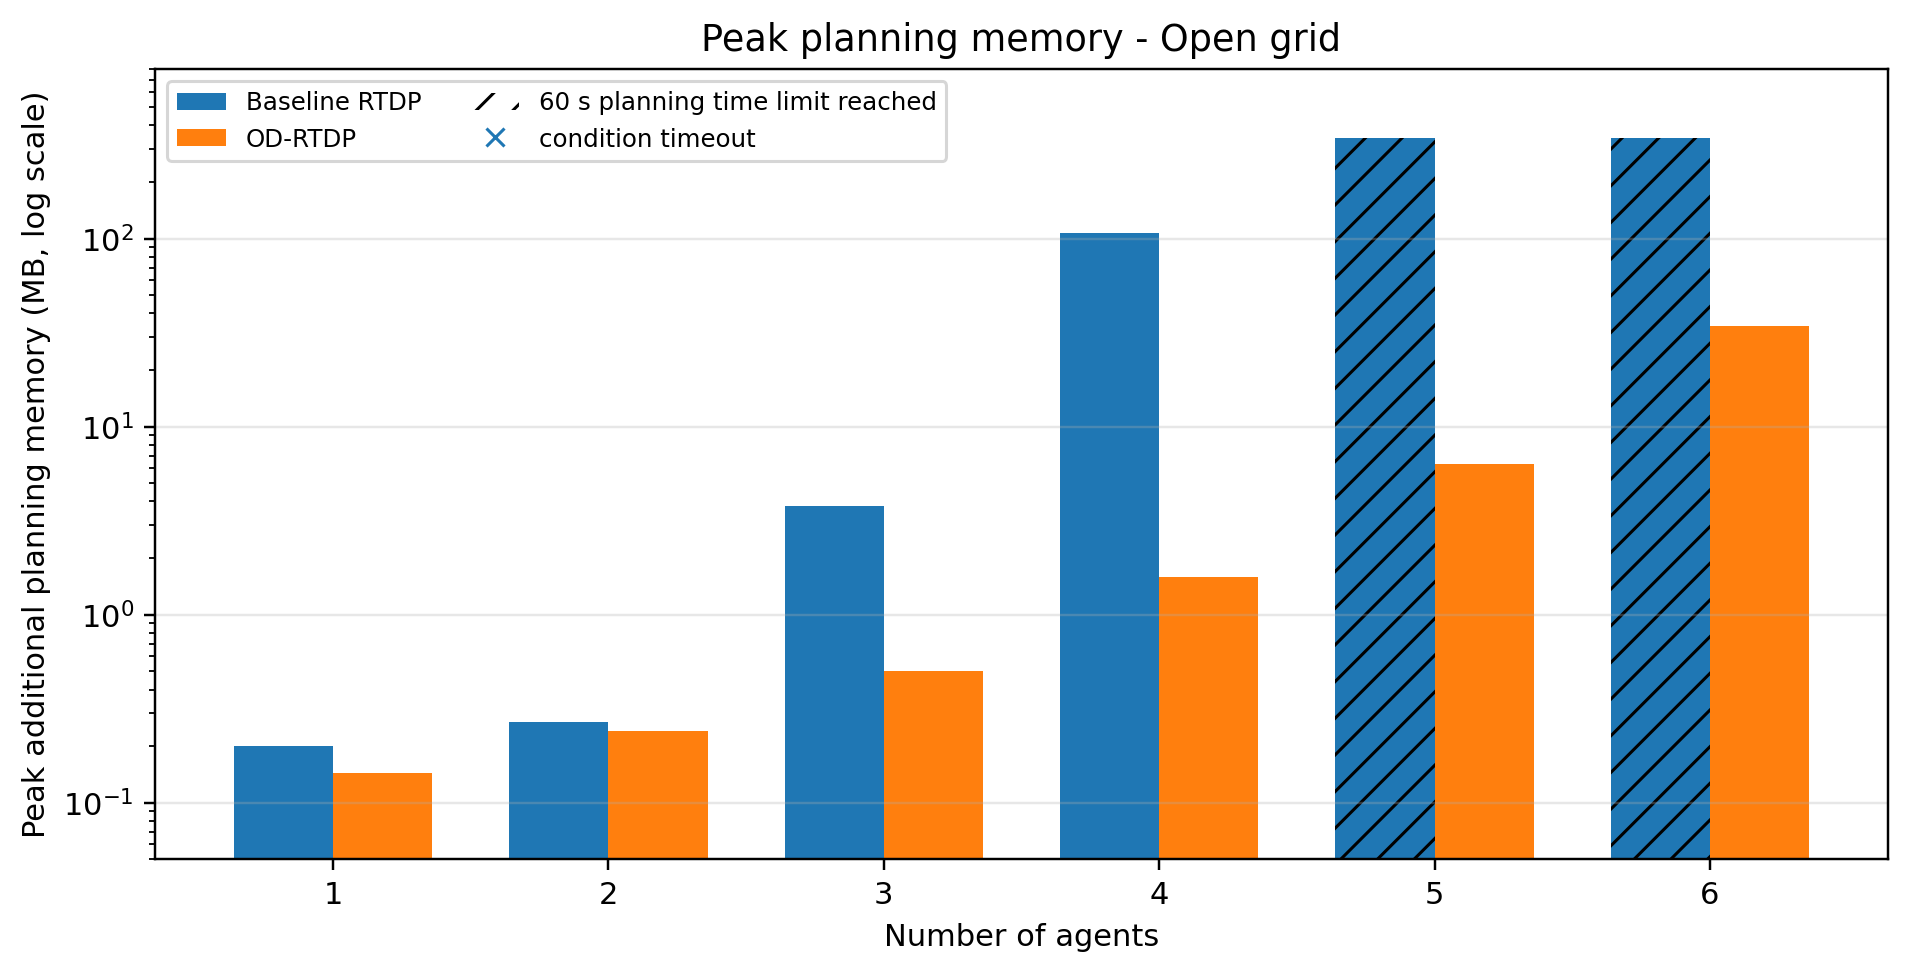

## Planning outcomes — Open-grid

,Agents,Baseline RTDP,OD-RTDP,Comparison
0,1,0.0012 s - solved,0.0021 s - solved,Baseline 1.8x faster
1,2,0.0061 s - solved,0.0085 s - solved,Baseline 1.4x faster
2,3,0.2000 s - solved,0.0491 s - solved,OD 4.1x faster
3,4,7.9701 s - solved,0.3783 s - solved,OD 21.1x faster
4,5,60.0004 s - time limit,2.8722 s - solved,Only OD converged
5,6,60.0194 s - time limit,16.2720 s - solved,Only OD converged



Single CSV: /content/MMDP_OUTPUT/MMDP_results_final_report.csv
Final-report outputs: /content/MMDP_OUTPUT/final_report_outputs
Nothing is downloaded automatically; use the Files panel to download manually.


In [5]:
run_and_analyze("easy")

## Medium map

Map: `warehouse-10-20-10-2-1`.

In [6]:
def _plot_med(num_agents):
    plot_map_visualization('warehouse-10-20-10-2-1', 'warehouse-10-20-10-2-1-bundled-1', num_agents)
interact(_plot_med, num_agents=IntSlider(min=1, max=6, step=1, value=4, description='Agents:'))

interactive(children=(IntSlider(value=4, description='Agents:', max=6, min=1), Output()), _dom_classes=('widge…

<function __main__._plot_med(num_agents)>

Starting the medium experiment: warehouse-10-20-10-2-1
12 serial conditions: 1 map x 6 agent counts x 2 algorithms
Fixed seed: 20260708
Group medium: 12 conditions (serial execution)
Fixed seed: 20260708
START   [1/12] warehouse-10-20-10-2-1 | agents=1 | baseline
DONE    [1/12] warehouse-10-20-10-2-1 | agents=1 | baseline | stop=initial_state_solved | plan=0.007s | memory=0.16MB | success=5/5 | total=0.2s
START   [2/12] warehouse-10-20-10-2-1 | agents=1 | od
DONE    [2/12] warehouse-10-20-10-2-1 | agents=1 | od | stop=initial_state_solved | plan=0.032s | memory=0.16MB | success=5/5 | total=0.2s
START   [3/12] warehouse-10-20-10-2-1 | agents=2 | baseline
DONE    [3/12] warehouse-10-20-10-2-1 | agents=2 | baseline | stop=initial_state_solved | plan=3.142s | memory=42.46MB | success=5/5 | total=3.9s
START   [4/12] warehouse-10-20-10-2-1 | agents=2 | od
DONE    [4/12] warehouse-10-20-10-2-1 | agents=2 | od | stop=initial_state_solved | plan=4.415s | memory=9.73MB | success=5/5 | total=5.3s

## Peak planning memory — medium

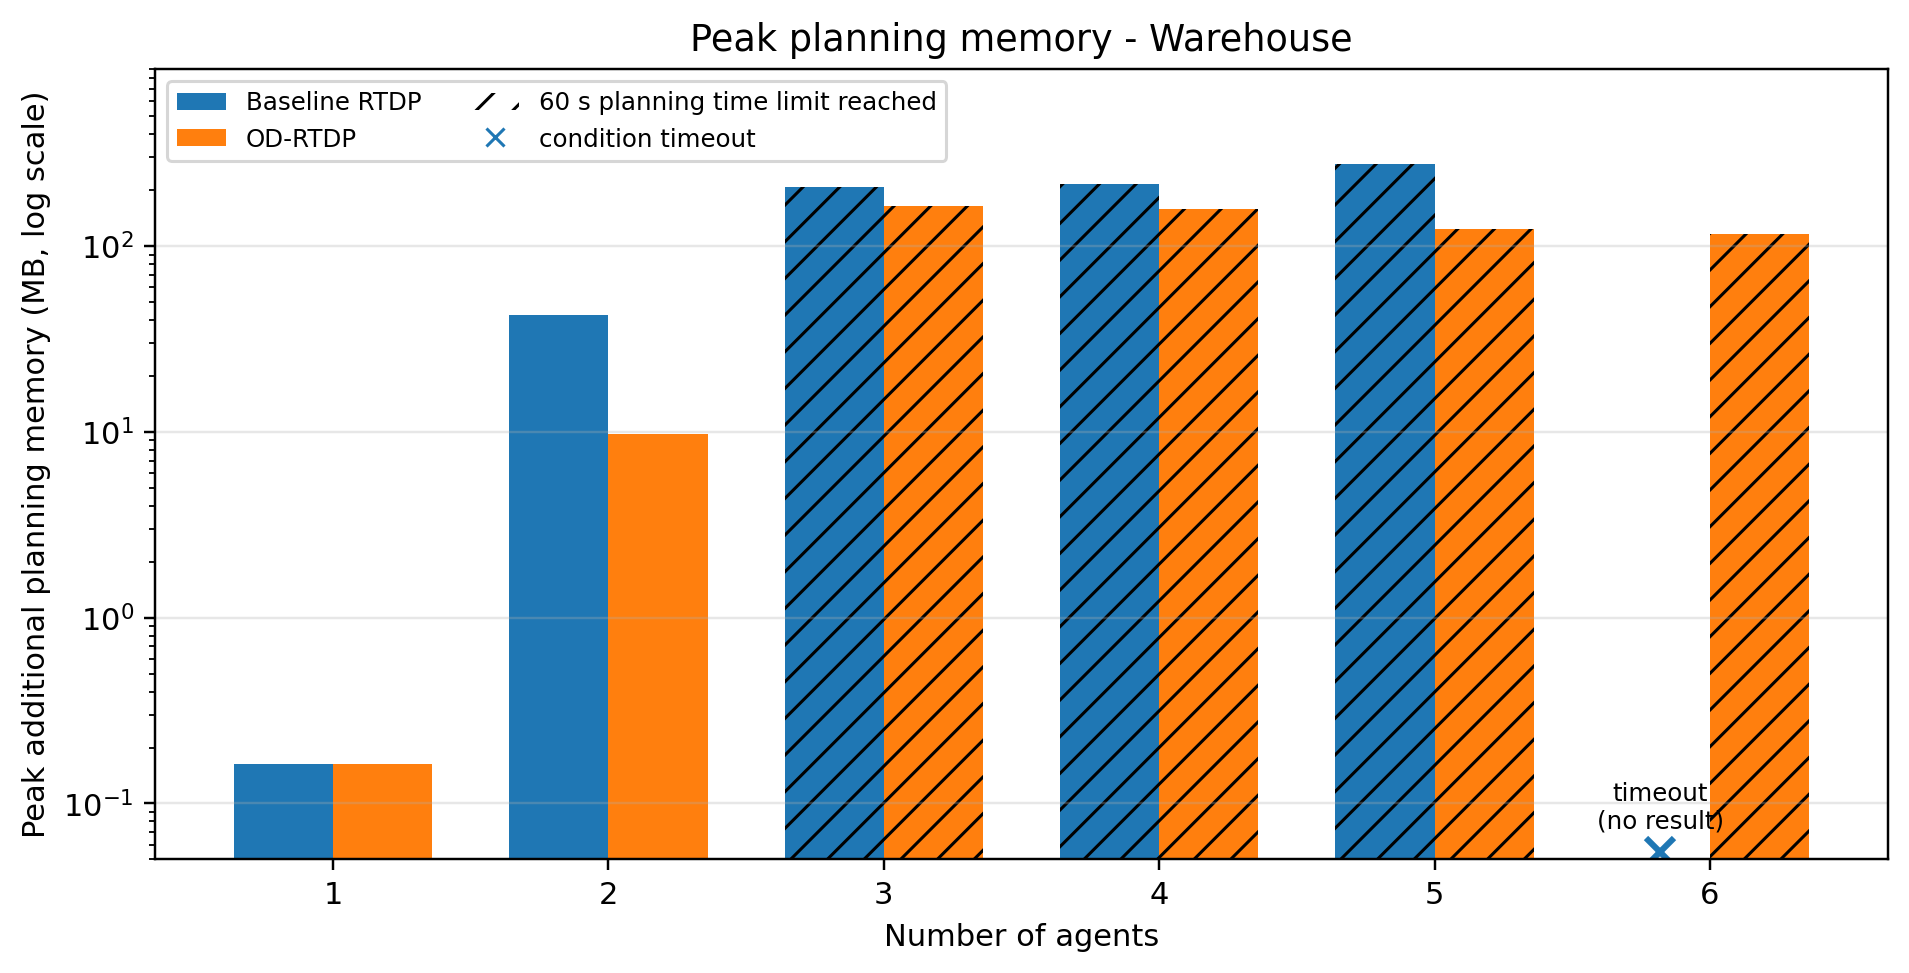

## Planning outcomes — Warehouse

,Agents,Baseline RTDP,OD-RTDP,Comparison
0,1,0.0071 s - solved,0.0322 s - solved,Baseline 4.5x faster
1,2,3.1424 s - solved,4.4154 s - solved,Baseline 1.4x faster
2,3,60.0005 s - time limit,60.0026 s - time limit,Neither planner converged
3,4,60.0005 s - time limit,60.0010 s - time limit,Neither planner converged
4,5,60.0003 s - time limit,60.0018 s - time limit,Neither planner converged
5,6,NA - condition timeout,60.0046 s - time limit,At least one condition timed out



Single CSV: /content/MMDP_OUTPUT/MMDP_results_final_report.csv
Final-report outputs: /content/MMDP_OUTPUT/final_report_outputs
Nothing is downloaded automatically; use the Files panel to download manually.


In [7]:
run_and_analyze("medium")

## Hard map

Map: `room-64-64-16`.

In [8]:
def _plot_hard(num_agents):
    plot_map_visualization('room-64-64-16', 'room-64-64-16-even-1', num_agents)
interact(_plot_hard, num_agents=IntSlider(min=1, max=6, step=1, value=6, description='Agents:'))

interactive(children=(IntSlider(value=6, description='Agents:', max=6, min=1), Output()), _dom_classes=('widge…

<function __main__._plot_hard(num_agents)>

Starting the hard experiment: room-64-64-16
12 serial conditions: 1 map x 6 agent counts x 2 algorithms
Fixed seed: 20260708
Group hard: 12 conditions (serial execution)
Fixed seed: 20260708
START   [1/12] room-64-64-16 | agents=1 | baseline
DONE    [1/12] room-64-64-16 | agents=1 | baseline | stop=initial_state_solved | plan=0.026s | memory=0.36MB | success=5/5 | total=0.2s
START   [2/12] room-64-64-16 | agents=1 | od
DONE    [2/12] room-64-64-16 | agents=1 | od | stop=initial_state_solved | plan=0.075s | memory=0.52MB | success=5/5 | total=0.3s
START   [3/12] room-64-64-16 | agents=2 | baseline
DONE    [3/12] room-64-64-16 | agents=2 | baseline | stop=time_limit | plan=60.000s | memory=151.88MB | success=5/5 | total=60.6s
START   [4/12] room-64-64-16 | agents=2 | od
DONE    [4/12] room-64-64-16 | agents=2 | od | stop=time_limit | plan=60.000s | memory=37.49MB | success=5/5 | total=60.9s
START   [5/12] room-64-64-16 | agents=3 | baseline
DONE    [5/12] room-64-64-16 | agents=3 | basel

## Peak planning memory — hard

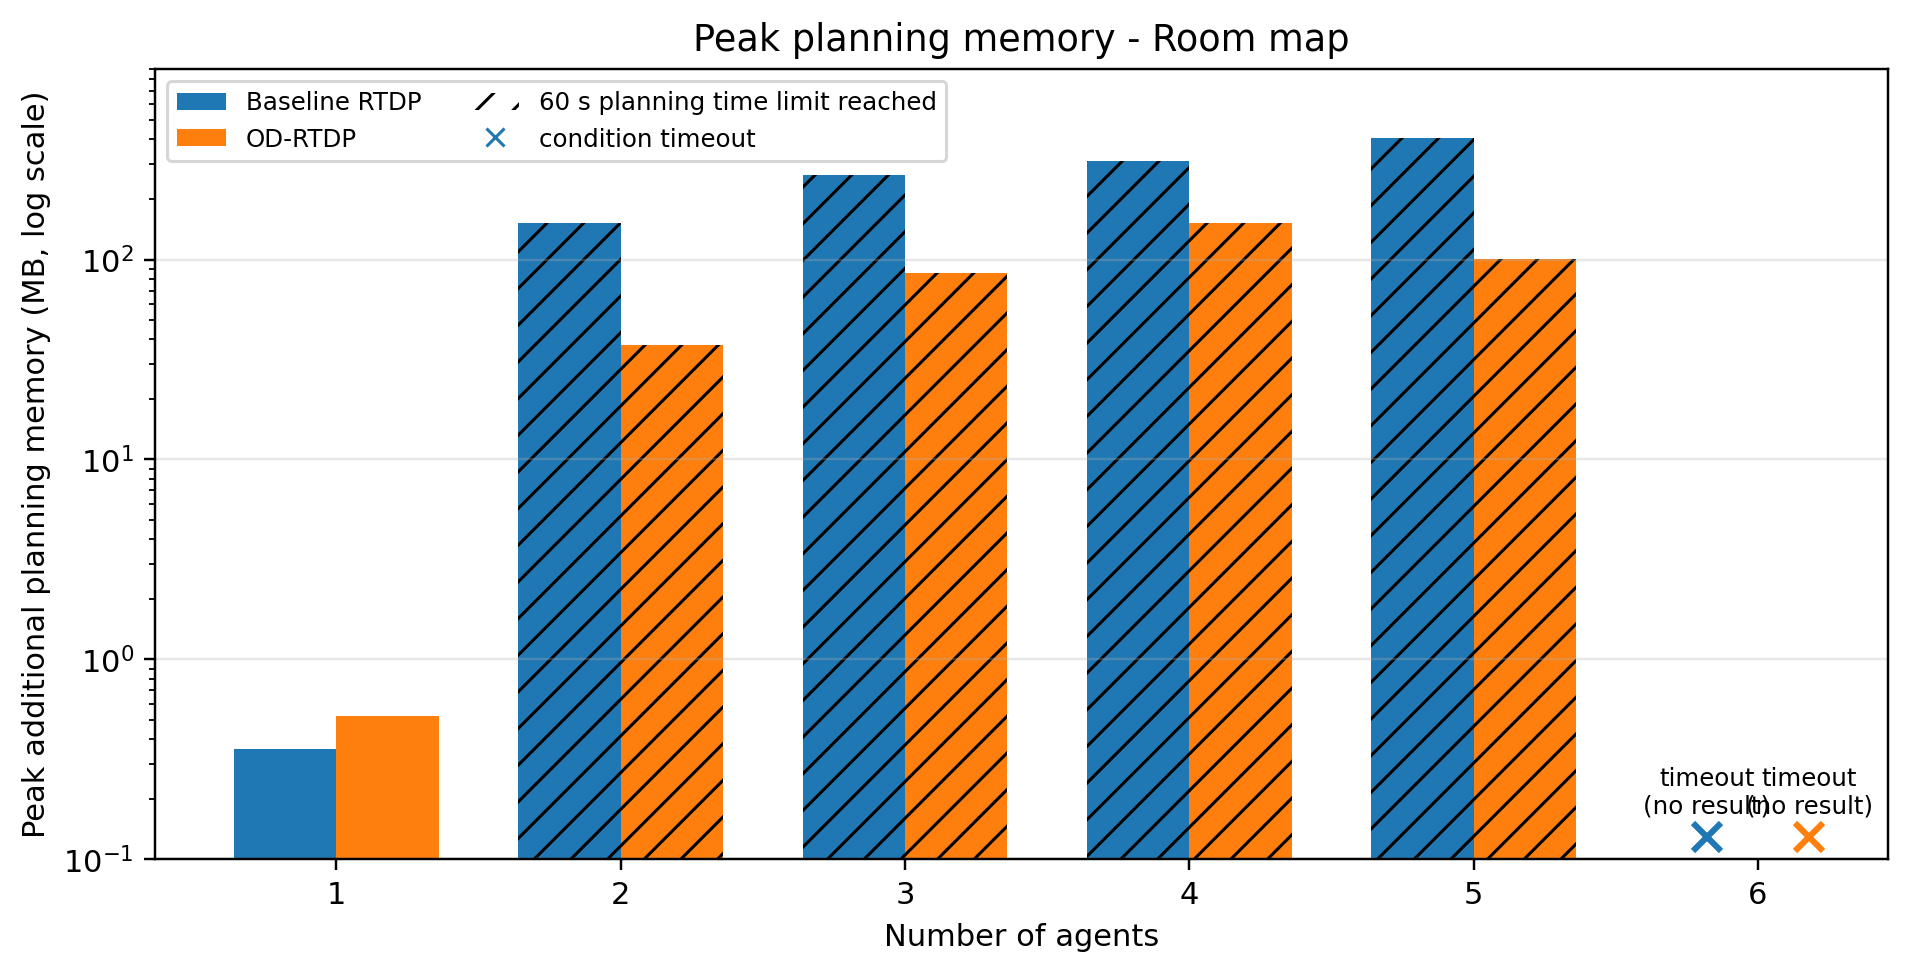

## Planning outcomes — Room-map

,Agents,Baseline RTDP,OD-RTDP,Comparison
0,1,0.0263 s - solved,0.0747 s - solved,Baseline 2.8x faster
1,2,60.0002 s - time limit,60.0004 s - time limit,Neither planner converged
2,3,60.0003 s - time limit,60.0004 s - time limit,Neither planner converged
3,4,60.0042 s - time limit,60.0035 s - time limit,Neither planner converged
4,5,60.0003 s - time limit,60.0108 s - time limit,Neither planner converged
5,6,NA - condition timeout,NA - condition timeout,At least one condition timed out


## Table 2 — Successful evaluation episodes out of five scheduled episodes

,Agents,Open B,Open OD,Warehouse B,Warehouse OD,Room B,Room OD
0,1,5/5,5/5,5/5,5/5,5/5,5/5
1,2,5/5,5/5,5/5,5/5,5/5,5/5
2,3,5/5,5/5,5/5,5/5,5/5,4/5
3,4,5/5,5/5,5/5,5/5,2/5,1/5
4,5,5/5,5/5,4/5,5/5,0/5,0/5
5,6,4/5,5/5,0/5 (timeout),3/5,0/5 (timeout),0/5 (timeout)



Single CSV: /content/MMDP_OUTPUT/MMDP_results_final_report.csv
Final-report outputs: /content/MMDP_OUTPUT/final_report_outputs
Nothing is downloaded automatically; use the Files panel to download manually.


In [9]:
run_and_analyze("hard")

## Output

The folder `/content/MMDP_OUTPUT` contains:

- `MMDP_results_final_report.csv` — one row per experimental condition
- `final_report_outputs/figure_1a_open_grid_peak_planning_memory.png`
- `final_report_outputs/figure_1b_warehouse_peak_planning_memory.png`
- `final_report_outputs/figure_1c_room_peak_planning_memory.png`
- `final_report_outputs/table_1_open_grid_planning_outcomes.csv`
- `final_report_outputs/table_1_warehouse_planning_outcomes.csv`
- `final_report_outputs/table_1_room_planning_outcomes.csv`
- `final_report_outputs/table_2_budgeted_policy_evaluation.csv`

The runner resumes from the existing CSV and skips every recorded `run_id`.
Delete the CSV or use a new output path to start a complete experiment from the
beginning.

In the memory figures, hatched bars mean that the **60-second planning time limit** was reached. They do not indicate a memory limit.


In [ ]:
# Display every available result table and figure.
show_final_report_outputs()
